In [15]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

print("Semua library berhasil dimuat!")

Semua library berhasil dimuat!


In [ ]:
# Sesuaikan path ini dengan lokasi folder dataset Anda
DATASET_PATH = "kayuin/Dataset_Tubes" # Contoh: "./dataset/"

# Parameter Audio & MFCC
MAX_DURATION = 3.0       # Maksimal durasi 3 detik
SAMPLE_RATE = 22050      # Standar sample rate librosa
N_MFCC = 40              # Jumlah koefisien MFCC (tinggi gambar/matriks)

# Menghitung panjang maksimal frame (lebar gambar/matriks)
# Rumus standar librosa: (sample_rate * duration) / hop_length (default 512)
MAX_PAD_LEN = int((SAMPLE_RATE * MAX_DURATION) / 512) + 1 
print(f"Dimensi input MFCC nantinya: ({N_MFCC}, {MAX_PAD_LEN}, 1)")

Dimensi input MFCC nantinya: (40, 130, 1)


In [4]:
def extract_mfcc(file_path):
    try:
        # Load audio
        audio, sr = librosa.load(file_path, sr=SAMPLE_RATE, duration=MAX_DURATION)
        
        # Ekstrak MFCC
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC)
        
        # Padding atau Truncating agar lebarnya seragam (MAX_PAD_LEN)
        pad_width = MAX_PAD_LEN - mfcc.shape[1]
        
        if pad_width > 0:
            # Jika audio kependekan, tambahkan padding 0 di akhir
            mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            # Jika kepanjangan, potong sesuai batas
            mfcc = mfcc[:, :MAX_PAD_LEN]
            
        return mfcc
    except Exception as e:
        print(f"Error memproses {file_path}: {e}")
        return None

In [5]:
X = []
y = []

print("Mulai memproses dataset...")

# Looping ke setiap folder class
for class_folder in os.listdir(DATASET_PATH):
    folder_path = os.path.join(DATASET_PATH, class_folder)
    
    # Pastikan itu adalah sebuah direktori
    if os.path.isdir(folder_path):
        print(f"Memproses class: {class_folder}...")
        
        for file_name in os.listdir(folder_path):
            if file_name.endswith('.wav'):
                file_path = os.path.join(folder_path, file_name)
                
                # Ekstrak MFCC
                mfcc_data = extract_mfcc(file_path)
                
                if mfcc_data is not None:
                    X.append(mfcc_data)
                    y.append(class_folder) # Gunakan nama folder sebagai label

print(f"Selesai! Total data: {len(X)} sampel.")

Mulai memproses dataset...
Memproses class: data_set_Cendana_1_25...
Memproses class: data_set_Eboni_1_25...
Memproses class: data_set_Jati_1_25...
Memproses class: data_set_Kempas_1_25...
Memproses class: data_set_Mahoni_1_25...
Memproses class: data_set_Matoa_1_25...
Memproses class: data_set_Meranti_1_25...
Memproses class: data_set_Nyatoh_1_25...
Memproses class: data_set_Pinus_1_25...
Memproses class: data_set_ulin_1_25...
Selesai! Total data: 250 sampel.


In [6]:
# Convert list ke numpy array
X = np.array(X)
y = np.array(y)

# Reshape X untuk CNN: (batch, N_MFCC, MAX_PAD_LEN, 1 channel)
X = X.reshape(X.shape[0], X.shape[1], X.shape[2], 1)

# Encode label (misal: "1", "2" -> 0, 1 -> [1,0,0,0,0], [0,1,0,0,0])
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

# Split data: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)

print(f"Shape X_train: {X_train.shape}")
print(f"Shape y_train: {y_train.shape}")
print(f"Class yang terdeteksi: {label_encoder.classes_}")

Shape X_train: (200, 40, 130, 1)
Shape y_train: (200, 10)
Class yang terdeteksi: ['data_set_Cendana_1_25' 'data_set_Eboni_1_25' 'data_set_Jati_1_25'
 'data_set_Kempas_1_25' 'data_set_Mahoni_1_25' 'data_set_Matoa_1_25'
 'data_set_Meranti_1_25' 'data_set_Nyatoh_1_25' 'data_set_Pinus_1_25'
 'data_set_ulin_1_25']


In [7]:
input_shape = (N_MFCC, MAX_PAD_LEN, 1)
num_classes = len(label_encoder.classes_)

model = Sequential([
    # Layer Konvolusi 1
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),

    # Layer Konvolusi 2
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),
    
    # Layer Konvolusi 3 (Opsional, gunakan jika dataset banyak)
    Conv2D(128, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3),

    # Flatten (Ubah matriks jadi array 1D)
    Flatten(),

    # Hidden / Dense Layer
    Dense(256, activation='relu'),
    Dropout(0.5), # Dropout besar di akhir agar tidak menghafal data train

    # Output Layer (Softmax untuk klasifikasi lebih dari 2 kelas)
    Dense(num_classes, activation='softmax')
])

# Compile Model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

c:\Users\mfaiz\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 38, 128, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 19, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 19, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 17, 62, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 31, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 31, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 29, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 14, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 14, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5376)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,376,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,471,754 (5.61 MB)

 Trainable params: 1,471,754 (5.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
EPOCHS = 30
BATCH_SIZE = 32

print("Memulai proses training...")
history = model.fit(
    X_train, 
    y_train, 
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE, 
    validation_data=(X_test, y_test)
)

Memulai proses training...
Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 120ms/step - accuracy: 0.0900 - loss: 22.2433 - val_accuracy: 0.1600 - val_loss: 2.3069
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.1050 - loss: 3.9986 - val_accuracy: 0.1800 - val_loss: 2.3487
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.1400 - loss: 2.4600 - val_accuracy: 0.2000 - val_loss: 2.2727
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.1400 - loss: 2.3415 - val_accuracy: 0.2600 - val_loss: 2.2414
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.1650 - loss: 2.2591 - val_accuracy: 0.4600 - val_loss: 2.2039
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.2150 - loss: 2.1912 - val_accuracy: 0.2800 - val_loss: 2.0763
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.3150 - loss: 2.0169 - val_accuracy: 0.4600 - val_loss: 1.8662
Epoch 8/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.2950 - loss: 1.9549 - val_accurac

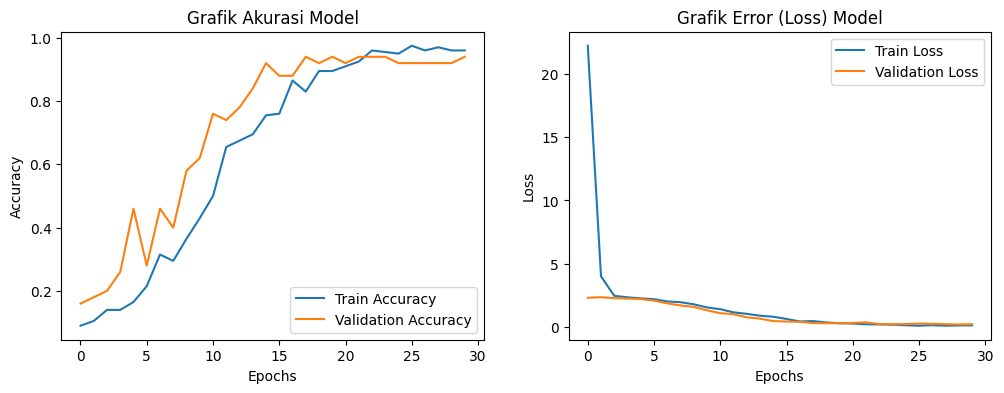

In [9]:
# Plot Akurasi
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Grafik Akurasi Model')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss (Error)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Grafik Error (Loss) Model')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [10]:
# Evaluasi pada data test
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Akurasi pada Data Testing: {test_acc * 100:.2f}%")

# Simpan model untuk digunakan nanti di aplikasi
model.save("voice_recognition_cnn.h5")
print("Model berhasil disimpan sebagai 'voice_recognition_cnn.h5'")

Akurasi pada Data Testing: 94.00%
Model berhasil disimpan sebagai 'voice_recognition_cnn.h5'
